##### Group Members:
1. Anjana M - 2023UG000090
2. Chanda - 2023UG000093
3. Kavita - 2023UG000078
4. Shivshankar - 2023UG000109
##### **Workforce Cost Optimization & Productivity Analysis**

###### Big Data and Cloud Computing Technologies Project

###### Problem Statement
How can organizations improve profitability by efficiently reallocating employees and integrating AI tools to enhance productivity while reducing operational costs without reducing workforce strength?

###### Objective
The objective of this project is to analyze a large employee workforce dataset using PySpark, perform data cleaning, transformations, and aggregations, and generate meaningful insights related to workforce cost optimization and productivity analysis.

Installing Pyspark

In [ ]:
!pip install pyspark openpyxl

##### Step 1: Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer

##### Step 2: Data Loading

In this step, the Excel dataset is uploaded manually into Google Colab.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Employee_Performance_and_Productivity_Data.xlsx to Employee_Performance_and_Productivity_Data.xlsx


##### Step 3: Read the Excel File Using Pandas

The uploaded Excel file is read using pandas and then converted into a Spark DataFrame.

In [ ]:
file_path = "Employee_Performance_and_Productivity_Data.xlsx"   # keep the exact uploaded file name here

df_pd = pd.read_excel(file_path, engine="openpyxl")

print("Pandas DataFrame Shape:", df_pd.shape)
df_pd.head()

Pandas DataFrame Shape: (100000, 20)


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556,2,High School,5,6750,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556,0,High School,5,7500,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556,8,High School,3,5850,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556,7,Bachelor,2,4800,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556,3,Bachelor,2,4800,38,11,29,13,100,15,9,1,1.25,False


##### Step 4: Create Spark Session

In [ ]:
spark = SparkSession.builder \
    .appName("Workforce_Cost_Optimization_Project") \
    .getOrCreate()

##### Step 5: Convert Pandas DataFrame to Spark DataFrame

In [ ]:
df = spark.createDataFrame(df_pd)

##### Step 6: View Schema, Sample Data, Rows, and Columns

In [ ]:
df.printSchema()
df.show(5, truncate=False)

print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))
print("Column names:", df.columns)

root
 |-- Employee_ID: long (nullable = true)
 |-- Department: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Job_Title: string (nullable = true)
 |-- Hire_Date: timestamp (nullable = true)
 |-- Years_At_Company: long (nullable = true)
 |-- Education_Level: string (nullable = true)
 |-- Performance_Score: long (nullable = true)
 |-- Monthly_Salary: long (nullable = true)
 |-- Work_Hours_Per_Week: long (nullable = true)
 |-- Projects_Handled: long (nullable = true)
 |-- Overtime_Hours: long (nullable = true)
 |-- Sick_Days: long (nullable = true)
 |-- Remote_Work_Frequency: long (nullable = true)
 |-- Team_Size: long (nullable = true)
 |-- Training_Hours: long (nullable = true)
 |-- Promotions: long (nullable = true)
 |-- Employee_Satisfaction_Score: double (nullable = true)
 |-- Resigned: boolean (nullable = true)

+-----------+----------------+------+---+----------+-----------------------+----------------+---------------+----------

Data Cleaning

##### Step 7: Check Null Values

In [ ]:
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns
])

null_counts.show(truncate=False)

+-----------+----------+------+---+---------+---------+----------------+---------------+-----------------+--------------+-------------------+----------------+--------------+---------+---------------------+---------+--------------+----------+---------------------------+--------+
|Employee_ID|Department|Gender|Age|Job_Title|Hire_Date|Years_At_Company|Education_Level|Performance_Score|Monthly_Salary|Work_Hours_Per_Week|Projects_Handled|Overtime_Hours|Sick_Days|Remote_Work_Frequency|Team_Size|Training_Hours|Promotions|Employee_Satisfaction_Score|Resigned|
+-----------+----------+------+---+---------+---------+----------------+---------------+-----------------+--------------+-------------------+----------------+--------------+---------+---------------------+---------+--------------+----------+---------------------------+--------+
|0          |0         |0     |0  |0        |0        |0               |0              |0                |0             |0                  |0               |0    

##### Step 8: Remove Duplicate Rows

In [ ]:
print("Rows before removing duplicates:", df.count())
df = df.dropDuplicates()
print("Rows after removing duplicates:", df.count())

Rows before removing duplicates: 100000
Rows after removing duplicates: 100000


##### Step 9: Convert Date Column Properly

In [ ]:
df = df.withColumn("Hire_Date", F.to_date(F.col("Hire_Date")))
df.printSchema()

root
 |-- Employee_ID: long (nullable = true)
 |-- Department: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Job_Title: string (nullable = true)
 |-- Hire_Date: date (nullable = true)
 |-- Years_At_Company: long (nullable = true)
 |-- Education_Level: string (nullable = true)
 |-- Performance_Score: long (nullable = true)
 |-- Monthly_Salary: long (nullable = true)
 |-- Work_Hours_Per_Week: long (nullable = true)
 |-- Projects_Handled: long (nullable = true)
 |-- Overtime_Hours: long (nullable = true)
 |-- Sick_Days: long (nullable = true)
 |-- Remote_Work_Frequency: long (nullable = true)
 |-- Team_Size: long (nullable = true)
 |-- Training_Hours: long (nullable = true)
 |-- Promotions: long (nullable = true)
 |-- Employee_Satisfaction_Score: double (nullable = true)
 |-- Resigned: boolean (nullable = true)



##### Step 10: Fill Missing Values

Numeric null values are filled with 0 and categorical null values are filled with 'Unknown'.

In [ ]:
numeric_fill_values = {
    "Age": 0,
    "Years_At_Company": 0,
    "Performance_Score": 0,
    "Monthly_Salary": 0,
    "Work_Hours_Per_Week": 0,
    "Projects_Handled": 0,
    "Overtime_Hours": 0,
    "Sick_Days": 0,
    "Remote_Work_Frequency": 0,
    "Team_Size": 0,
    "Training_Hours": 0,
    "Promotions": 0,
    "Employee_Satisfaction_Score": 0.0
}

categorical_fill_values = {
    "Department": "Unknown",
    "Gender": "Unknown",
    "Job_Title": "Unknown",
    "Education_Level": "Unknown"
}

df = df.fillna(numeric_fill_values)
df = df.fillna(categorical_fill_values)

print("Missing values handled.")

Missing values handled.


##### Step 11: Remove Unwanted Identifier Column

Employee_ID is only an identifier, so it is removed from the cleaned analytical dataset.

In [ ]:
df_clean = df.drop("Employee_ID")
print(df_clean.columns)

['Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date', 'Years_At_Company', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned']


##### Step 12: Convert Boolean Feature to Numeric

The Resigned column is converted into numeric format:
- True = 1
- False = 0

In [ ]:
df_clean = df_clean.withColumn(
    "Resigned_Numeric",
    F.when(F.col("Resigned") == True, 1).otherwise(0)
)

df_clean.select("Resigned", "Resigned_Numeric").show(5)

+--------+----------------+
|Resigned|Resigned_Numeric|
+--------+----------------+
|   false|               0|
|   false|               0|
|   false|               0|
|   false|               0|
|   false|               0|
+--------+----------------+
only showing top 5 rows


##### Step 13: Convert Non-Numeric Features to Numeric

Categorical columns are indexed so they can also be used in numeric analysis if needed.

In [ ]:
categorical_columns = ["Department", "Gender", "Job_Title", "Education_Level"]

for col_name in categorical_columns:
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_Index", handleInvalid="keep")
    df_clean = indexer.fit(df_clean).transform(df_clean)

df_clean.select(
    "Department", "Department_Index",
    "Gender", "Gender_Index",
    "Job_Title", "Job_Title_Index",
    "Education_Level", "Education_Level_Index"
).show(5, truncate=False)

+----------------+----------------+------+------------+----------+---------------+---------------+---------------------+
|Department      |Department_Index|Gender|Gender_Index|Job_Title |Job_Title_Index|Education_Level|Education_Level_Index|
+----------------+----------------+------+------------+----------+---------------+---------------+---------------------+
|Legal           |5.0             |Male  |0.0         |Technician|2.0            |Bachelor       |0.0                  |
|Customer Support|6.0             |Female|1.0         |Developer |6.0            |Bachelor       |0.0                  |
|Customer Support|6.0             |Male  |0.0         |Specialist|0.0            |High School    |1.0                  |
|Finance         |1.0             |Female|1.0         |Manager   |1.0            |High School    |1.0                  |
|Operations      |2.0             |Male  |0.0         |Engineer  |4.0            |Bachelor       |0.0                  |
+----------------+--------------

##### Step 14: Descriptive Statistics

In [ ]:
df_clean.describe().show()

+-------+----------------+------+------------------+----------+------------------+---------------+------------------+------------------+-------------------+------------------+----------------+-----------------+---------------------+-----------------+----------------+------------------+---------------------------+------------------+------------------+------------------+------------------+---------------------+
|summary|      Department|Gender|               Age| Job_Title|  Years_At_Company|Education_Level| Performance_Score|    Monthly_Salary|Work_Hours_Per_Week|  Projects_Handled|  Overtime_Hours|        Sick_Days|Remote_Work_Frequency|        Team_Size|  Training_Hours|        Promotions|Employee_Satisfaction_Score|  Resigned_Numeric|  Department_Index|      Gender_Index|   Job_Title_Index|Education_Level_Index|
+-------+----------------+------+------------------+----------+------------------+---------------+------------------+------------------+-------------------+------------------

##### Step 15: Transformations
Transsforamation is the process of creating or changing new columns. It helps to convert the raw values into maningful insights for eay comparison and analysis.

Three transformations are created:
1. Salary Category
2. Productivity Level
3. Overtime Status

In [ ]:
df_clean = df_clean.withColumn(
    "Salary_Category",
    F.when(F.col("Monthly_Salary") < 5000, "Low")
     .when((F.col("Monthly_Salary") >= 5000) & (F.col("Monthly_Salary") < 10000), "Medium")
     .otherwise("High")
)

df_clean.select("Monthly_Salary", "Salary_Category").show(10, truncate=False)

+--------------+---------------+
|Monthly_Salary|Salary_Category|
+--------------+---------------+
|4900          |Low            |
|5500          |Medium         |
|5400          |Medium         |
|8400          |Medium         |
|7800          |Medium         |
|5400          |Medium         |
|7200          |Medium         |
|7800          |Medium         |
|4800          |Low            |
|9000          |Medium         |
+--------------+---------------+
only showing top 10 rows


In [ ]:
df_clean = df_clean.withColumn(
    "Productivity_Level",
    F.when(F.col("Performance_Score") < 3, "Low")
     .when((F.col("Performance_Score") >= 3) & (F.col("Performance_Score") < 4), "Average")
     .otherwise("High")
)

df_clean.select("Performance_Score", "Productivity_Level").show(10, truncate=False)

+-----------------+------------------+
|Performance_Score|Productivity_Level|
+-----------------+------------------+
|4                |High              |
|1                |Low               |
|2                |Low               |
|4                |High              |
|3                |Average           |
|2                |Low               |
|2                |Low               |
|3                |Average           |
|2                |Low               |
|5                |High              |
+-----------------+------------------+
only showing top 10 rows


In [ ]:
df_clean = df_clean.withColumn(
    "Overtime_Status",
    F.when(F.col("Overtime_Hours") == 0, "No Overtime")
     .when((F.col("Overtime_Hours") > 0) & (F.col("Overtime_Hours") <= 10), "Moderate Overtime")
     .otherwise("High Overtime")
)

df_clean.select("Overtime_Hours", "Overtime_Status").show(10, truncate=False)

+--------------+-----------------+
|Overtime_Hours|Overtime_Status  |
+--------------+-----------------+
|4             |Moderate Overtime|
|23            |High Overtime    |
|22            |High Overtime    |
|0             |No Overtime      |
|14            |High Overtime    |
|7             |Moderate Overtime|
|13            |High Overtime    |
|26            |High Overtime    |
|25            |High Overtime    |
|21            |High Overtime    |
+--------------+-----------------+
only showing top 10 rows


In [ ]:
df_clean.select(
    "Department",
    "Monthly_Salary",
    "Salary_Category",
    "Performance_Score",
    "Productivity_Level",
    "Overtime_Hours",
    "Overtime_Status",
    "Resigned_Numeric"
).show(10, truncate=False)

+----------------+--------------+---------------+-----------------+------------------+--------------+-----------------+----------------+
|Department      |Monthly_Salary|Salary_Category|Performance_Score|Productivity_Level|Overtime_Hours|Overtime_Status  |Resigned_Numeric|
+----------------+--------------+---------------+-----------------+------------------+--------------+-----------------+----------------+
|Legal           |4900          |Low            |4                |High              |4             |Moderate Overtime|0               |
|Customer Support|5500          |Medium         |1                |Low               |23            |High Overtime    |0               |
|Customer Support|5400          |Medium         |2                |Low               |22            |High Overtime    |0               |
|Finance         |8400          |Medium         |4                |High              |0             |No Overtime      |0               |
|Operations      |7800          |Medium  

##### Step 16: Convert Transformation Columns to Numeric

The transformed categorical columns are converted into numeric index columns for final analytical dataset preparation.

In [ ]:
transform_columns = ["Salary_Category", "Productivity_Level", "Overtime_Status"]

for col_name in transform_columns:
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_Index", handleInvalid="keep")
    df_clean = indexer.fit(df_clean).transform(df_clean)

df_clean.select(
    "Salary_Category", "Salary_Category_Index",
    "Productivity_Level", "Productivity_Level_Index",
    "Overtime_Status", "Overtime_Status_Index"
).show(10, truncate=False)

+---------------+---------------------+------------------+------------------------+-----------------+---------------------+
|Salary_Category|Salary_Category_Index|Productivity_Level|Productivity_Level_Index|Overtime_Status  |Overtime_Status_Index|
+---------------+---------------------+------------------+------------------------+-----------------+---------------------+
|Low            |1.0                  |High              |1.0                     |Moderate Overtime|1.0                  |
|Medium         |0.0                  |Low               |0.0                     |High Overtime    |0.0                  |
|Medium         |0.0                  |Low               |0.0                     |High Overtime    |0.0                  |
|Medium         |0.0                  |High              |1.0                     |No Overtime      |2.0                  |
|Medium         |0.0                  |Average           |2.0                     |High Overtime    |0.0                  |
|Medium 

##### Step 17: Create Final Cleaned Numeric Dataset

In this step, unwanted identifier and original text columns are removed so that the final cleaned dataset is more suitable for analytical use.

In [ ]:
cols_to_drop = [c for c in [
    "Employee_ID",
    "Department",
    "Gender",
    "Job_Title",
    "Education_Level",
    "Resigned",
    "Salary_Category",
    "Productivity_Level",
    "Overtime_Status"
] if c in df_clean.columns]

df_numeric = df_clean.drop(*cols_to_drop)

print("Final numeric cleaned dataset columns:")
print(df_numeric.columns)

df_numeric.show(5, truncate=False)

Final numeric cleaned dataset columns:
['Age', 'Hire_Date', 'Years_At_Company', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned_Numeric', 'Department_Index', 'Gender_Index', 'Job_Title_Index', 'Education_Level_Index', 'Salary_Category_Index', 'Productivity_Level_Index', 'Overtime_Status_Index']
+---+----------+----------------+-----------------+--------------+-------------------+----------------+--------------+---------+---------------------+---------+--------------+----------+---------------------------+----------------+----------------+------------+---------------+---------------------+---------------------+------------------------+---------------------+
|Age|Hire_Date |Years_At_Company|Performance_Score|Monthly_Salary|Work_Hours_Per_Week|Projects_Handled|Overtime_Hours|Sick_Days|Remote_Work_Frequency|Team_Size

##### Step 18: Save Final Cleaned Numeric Dataset

The final cleaned numeric dataset is saved in CSV and Excel formats.

In [ ]:
df_numeric.coalesce(1).write.mode("overwrite").option("header", True).csv("final_numeric_cleaned_dataset")

import shutil
import glob

part_file = glob.glob("final_numeric_cleaned_dataset/part-*.csv")[0]
shutil.copy(part_file, "final_numeric_cleaned_dataset.csv")

df_numeric_pd = df_numeric.toPandas()
df_numeric_pd.to_excel("final_numeric_cleaned_dataset.xlsx", index=False)

print("Final numeric cleaned dataset saved successfully.")

Final numeric cleaned dataset saved successfully.


In [ ]:
from google.colab import files

files.download("final_numeric_cleaned_dataset.csv")
files.download("final_numeric_cleaned_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("final_numeric_cleaned_dataset.csv")
files.download("final_numeric_cleaned_dataset.xlsx")

##### Step 19: Aggregations
Aggregation is the process of combining many rows to summarise data by calculating values.

Three relevant aggregations are performed:
1. Department-wise average performance score
2. Department-wise average monthly salary
3. Productivity level distribution

In [ ]:
dept_performance = df_clean.groupBy("Department").agg(
    F.avg("Performance_Score").alias("avg_performance_score"),
    F.count("*").alias("employee_count")
)

dept_performance.show(truncate=False)

+----------------+---------------------+--------------+
|Department      |avg_performance_score|employee_count|
+----------------+---------------------+--------------+
|Sales           |2.9943355511598635   |11122         |
|Customer Support|2.997121266642677    |11116         |
|Engineering     |3.02026286966046     |10956         |
|HR              |2.9973540145985402   |10960         |
|Finance         |2.981160714285714    |11200         |
|Legal           |2.9817413203813636   |11118         |
|Marketing       |2.9806526390870185   |11216         |
|IT              |3.0                  |11131         |
|Operations      |3.0067972453268936   |11181         |
+----------------+---------------------+--------------+



In [ ]:
dept_salary = df_clean.groupBy("Department").agg(
    F.avg("Monthly_Salary").alias("avg_monthly_salary"),
    F.count("*").alias("employee_count")
)

dept_salary.show(truncate=False)

+----------------+------------------+--------------+
|Department      |avg_monthly_salary|employee_count|
+----------------+------------------+--------------+
|Sales           |6413.154108973206 |11122         |
|Customer Support|6403.881792011515 |11116         |
|Engineering     |6417.246257758306 |10956         |
|HR              |6400.355839416058 |10960         |
|Finance         |6398.575892857143 |11200         |
|Legal           |6391.275409246267 |11118         |
|Marketing       |6377.857524964336 |11216         |
|IT              |6414.598868026233 |11131         |
|Operations      |6412.306591539218 |11181         |
+----------------+------------------+--------------+



In [ ]:
productivity_distribution = df_clean.groupBy("Productivity_Level").agg(
    F.count("*").alias("employee_count")
)

productivity_distribution.show(truncate=False)

+------------------+--------------+
|Productivity_Level|employee_count|
+------------------+--------------+
|High              |39868         |
|Low               |40133         |
|Average           |19999         |
+------------------+--------------+



##### Step 20: Summary Table

In [ ]:
dept_summary = df_clean.groupBy("Department").agg(
    F.avg("Performance_Score").alias("avg_performance_score"),
    F.avg("Monthly_Salary").alias("avg_monthly_salary"),
    F.avg("Overtime_Hours").alias("avg_overtime_hours"),
    F.avg("Employee_Satisfaction_Score").alias("avg_satisfaction_score"),
    F.avg("Resigned_Numeric").alias("avg_resignation_rate"),
    F.count("*").alias("employee_count")
)

dept_summary.show(truncate=False)

+----------------+---------------------+------------------+------------------+----------------------+--------------------+--------------+
|Department      |avg_performance_score|avg_monthly_salary|avg_overtime_hours|avg_satisfaction_score|avg_resignation_rate|employee_count|
+----------------+---------------------+------------------+------------------+----------------------+--------------------+--------------+
|Sales           |2.9943355511598635   |6413.154108973206 |14.51375651861176 |2.993333932745901     |0.09926272253191872 |11122         |
|Customer Support|2.997121266642677    |6403.881792011515 |14.383951061532926|2.9680442605253634    |0.09877653832313782 |11116         |
|Engineering     |3.02026286966046     |6417.246257758306 |14.593282219788243|3.0029043446513306    |0.09647681635633443 |10956         |
|HR              |2.9973540145985402   |6400.355839416058 |14.577098540145986|2.9951085766423358    |0.10264598540145986 |10960         |
|Finance         |2.98116071428571

##### Step 21: Visualizations

In [ ]:
dept_performance_pd = dept_performance.toPandas()
dept_salary_pd = dept_salary.toPandas()
productivity_distribution_pd = productivity_distribution.toPandas()
dept_summary_pd = dept_summary.toPandas()

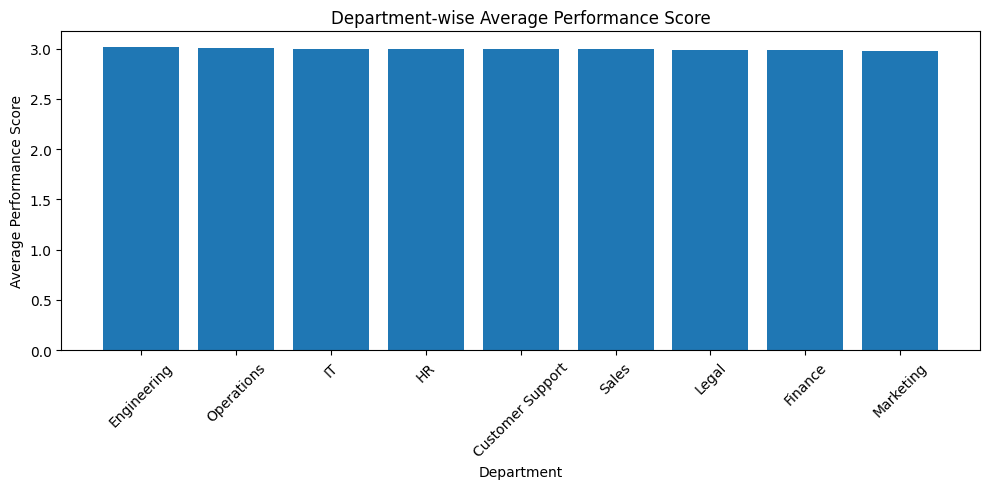

In [ ]:
dept_performance_pd = dept_performance_pd.sort_values(by="avg_performance_score", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(dept_performance_pd["Department"], dept_performance_pd["avg_performance_score"])
plt.xticks(rotation=45)
plt.title("Department-wise Average Performance Score")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")
plt.tight_layout()
plt.show()

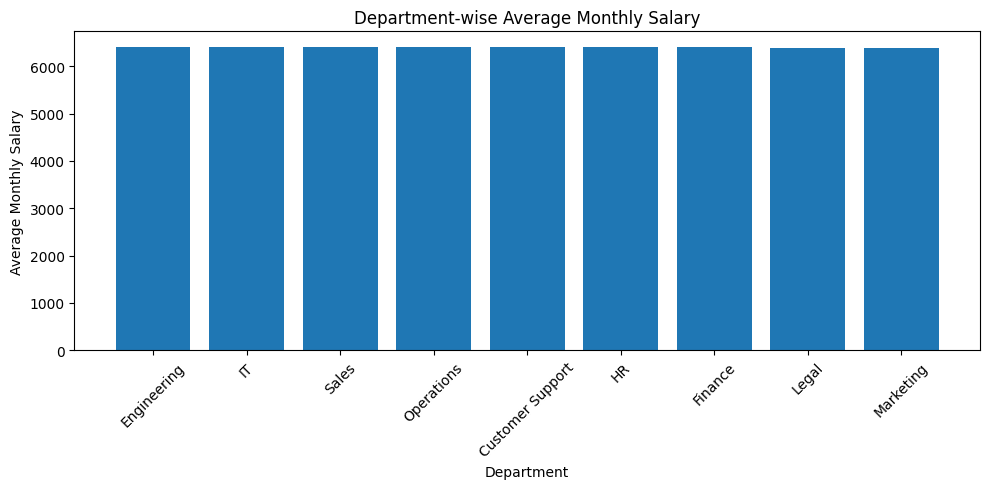

In [ ]:
dept_salary_pd = dept_salary_pd.sort_values(by="avg_monthly_salary", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(dept_salary_pd["Department"], dept_salary_pd["avg_monthly_salary"])
plt.xticks(rotation=45)
plt.title("Department-wise Average Monthly Salary")
plt.xlabel("Department")
plt.ylabel("Average Monthly Salary")
plt.tight_layout()
plt.show()

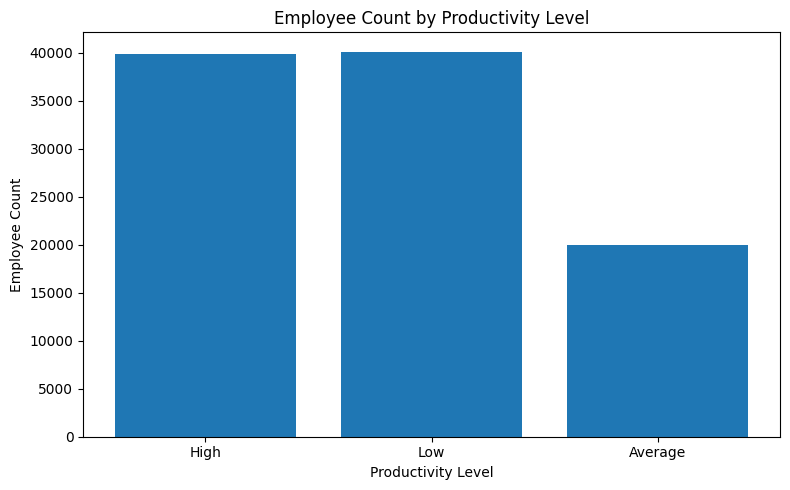

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(productivity_distribution_pd["Productivity_Level"], productivity_distribution_pd["employee_count"])
plt.title("Employee Count by Productivity Level")
plt.xlabel("Productivity Level")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()

##### Step 22: Save Output Files for Dashboard

In [ ]:
df_clean.coalesce(1).write.mode("overwrite").option("header", True).csv("processed_employee_data")

dept_performance_pd.to_csv("dept_performance.csv", index=False)
dept_salary_pd.to_csv("dept_salary.csv", index=False)
productivity_distribution_pd.to_csv("productivity_distribution.csv", index=False)
dept_summary_pd.to_csv("dept_summary.csv", index=False)

print("All output files saved successfully.")

All output files saved successfully.


##### Step 23: Download CSV Files

In [ ]:
from google.colab import files

files.download("dept_performance.csv")
files.download("dept_salary.csv")
files.download("productivity_distribution.csv")
files.download("dept_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##### Step 24: Conclusion

The dataset was successfully loaded, cleaned, transformed, aggregated, and visualized. The processed data can be used for dashboard creation and workforce cost optimization analysis.

In [ ]:
print("Project Completed Successfully")
print("1. Dataset loaded into PySpark")
print("2. Data cleaned and duplicates removed")
print("3. Missing values handled")
print("4. Non-numeric columns prepared where required")
print("5. Three transformations performed")
print("6. Three aggregations performed")
print("7. Visualizations generated")
print("8. Output files saved for dashboard creation")

Project Completed Successfully
1. Dataset loaded into PySpark
2. Data cleaned and duplicates removed
3. Missing values handled
4. Non-numeric columns prepared where required
5. Three transformations performed
6. Three aggregations performed
7. Visualizations generated
8. Output files saved for dashboard creation
